# The canonical detector

`D_h` is the paper's detector: a single logistic direction in the frozen CLIP ViT-L/14-336
representation. This notebook loads it, scores images, and shows what the score does *not* tell you.


In [1]:
import matplotlib.pyplot as plt
from PIL import Image
from pyprojroot import here

from clip_cues import list_available_models, load_clip_classifier

# Repo-relative paths, resolved from wherever the kernel happens to start.
ROOT = here()
CACHE = str(ROOT / "data" / "hf_cache")


/workspaces/clip-cues/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Which checkpoints exist

Four training corpora per family. The `linear_probe_*` checkpoints are `D_h`; the
`clip_orthogonal_*` k=8 heads are a **diagnostic ablation** whose individual axes are not
reproducible across seeds, so do not read them per-axis.


In [2]:
for name, info in list_available_models().items():
    print(f"{name:34s} {info['training_data']:14s} {info['type']}")


clip_orthogonal_synthclic          SynthCLIC      orthogonal
clip_orthogonal_synthbuster        SynthBuster+   orthogonal
clip_orthogonal_cnnspot            CNNSpot        orthogonal
clip_orthogonal_combined           Combined       orthogonal
linear_probe_synthclic             SynthCLIC      linear
linear_probe_synthbuster           SynthBuster+   linear
linear_probe_cnnspot               CNNSpot        linear
linear_probe_combined              Combined       linear
cm_antonyms_synthclic              SynthCLIC      concept
cm_antonyms_synthbuster            SynthBuster+   concept
cm_antonyms_cnnspot                CNNSpot        concept
cm_antonyms_combined               Combined       concept


## Load and predict

CLIP is downloaded once into `data/hf_cache`. Keep every cache in that one root, or the
model and dataset files get fetched a second time.


In [7]:
model = load_clip_classifier(
    str(ROOT / "data/checkpoints/linear_probe_synthclic.ckpt"),
    cache_dir=CACHE,
)

prob = model.predict(str(ROOT / "examples/images/synthetic1.png"))
print(f"P(synthetic) = {prob:.1%}")


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 11512.78it/s]
[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.

P(synthetic) = 53.4%


## A batch, and what the numbers look like


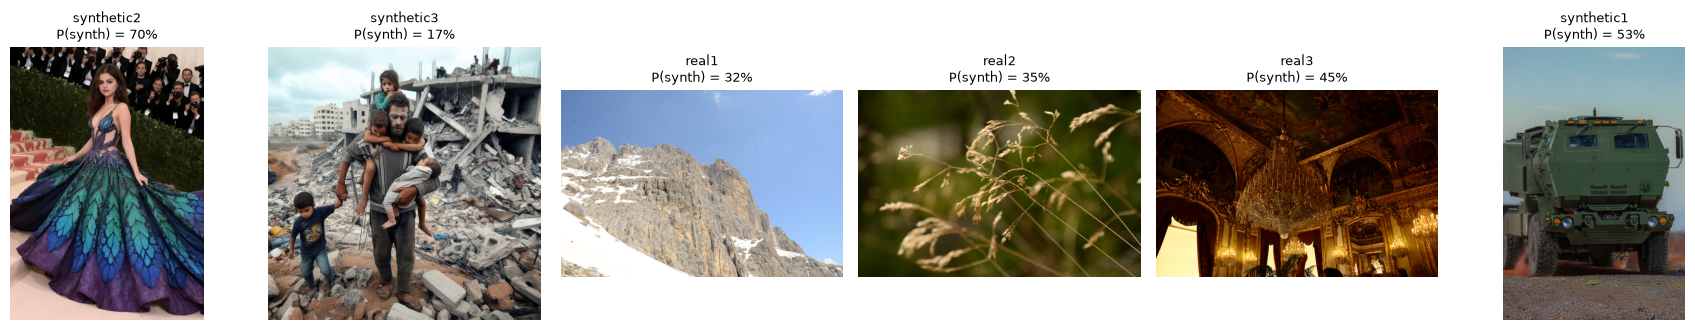

In [8]:
images = ROOT / "examples" / "images"
paths = sorted(images.glob("*.jpg")) + sorted(images.glob("*.png"))
probs = model.predict_batch([str(p) for p in paths], batch_size=8)

fig, axes = plt.subplots(1, len(paths), figsize=(3 * len(paths), 3.4))
for ax, p, q in zip(axes, paths, probs):
    ax.imshow(Image.open(p))
    ax.set_title(f"{p.stem}\nP(synth) = {q:.0%}", fontsize=9)
    ax.axis("off")
fig.tight_layout()


## Two caveats worth keeping in mind

**The detector is corpus-specific.** A head trained on SynthCLIC and one trained on CNNSpot key
on largely unrelated cues, and cross-family transfer is weak (0.42 mAP from SynthCLIC to
CNNSpot). Pick the checkpoint whose training corpus resembles your images, and treat scores on
very different material as unreliable.

**The direction is more stable than the images it ranks.** Across seeds the decision direction
agrees at 0.989, but the top-50 most-extreme image sets agree at only 0.73. An individual score
is a weaker statement than the aggregate.

Both effects are quantified in the paper's F1 and E4 experiments — see
[docs/EXPERIMENTS.md](../docs/EXPERIMENTS.md).
